# Quora Question Pairs - Duplicate Detection

**Goal:** Identify whether two Quora questions are semantically duplicate using hand crafted NLP features and SBERT embeddings, classified with XGBoost.

**Pipeline Overview:**
1. Data Loading & EDA
2. Text Preprocessing
3. Basic Feature Engineering
4. Advanced Token / Length / Fuzzy Features
5. SBERT Semantic Embedding Features
6. Model Training with Hyperparameter Tuning (XGBoost)
7. Evaluation: Confusion Matrix, Classification Report, Feature Importance
8. Model Persistence

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings("ignore")

print("All imports successful.")

All imports successful.


## 2. Data Loading

In [2]:
# Scanning around known bad rows before loading
with open("train.csv", "r", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= 2140 and i <= 2150:
            print(i, line)

2140 "2139","4256","4257","How can I recover a lost T-Mobile phone?","What are T-Mobile's lost phone policies?","0"

2141 "2140","4258","4259","Which DSLR camera is better Nikon D3300 and Canon EOS 1300D?","Which DSLR is better, Nikon D5500 or Canon EOS 60D?","0"

2142 "2141","4260","4261","Which moment in your life changed you completely?","What was the moment in your life that changed it completely?","1"

2143 "2142","4262","4263","If someone shares his Google Drive with me and in the future deletes a file in it, will that file be available to me in my Drive?","How do I save a shared file (shared with me) in my Google drive permanently (shared with me)?","0"

2144 "2143","4264","4265","How will the ban of Rs 500 and Rs 1000 notes affect Indian economy?","What are your views on India banning 500 and 1000 notes? In what way it will affect Indian economy?","1"

2145 "2144","4266","4267","What is the easiest way to hack a database?","How exactly do you hack a website/database?","0"

2146

In [3]:
df = pd.read_csv("train.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


# 3. Exploratory Data Analysis (EDA)
Before building any model, we must understand the data: class distribution, missing values, and the nature of the text.

In [4]:
# Basic info:
print("Shape:", df.shape)
print("Column names:", df.columns.tolist())
print("Data Types:", df.dtypes)
print("Missing values:", df.isnull().sum())

Shape: (404290, 6)
Column names: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']
Data Types: id               int64
qid1             int64
qid2             int64
question1       object
question2       object
is_duplicate     int64
dtype: object
Missing values: id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


Class Distribution:
               Count  Percentage
is_duplicate                    
0             255027       63.08
1             149263       36.92


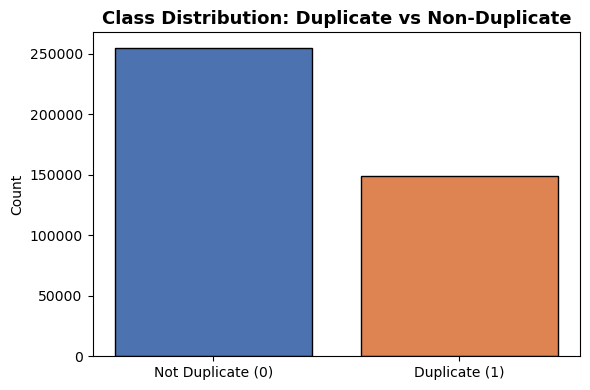

In [5]:
# ---- Class Balance -------------------------------------------------
class_counts = df["is_duplicate"].value_counts()
class_pct    = df["is_duplicate"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(pd.DataFrame({"Count": class_counts, "Percentage": class_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Not Duplicate (0)", "Duplicate (1)"], class_counts.values,
       color=["#4C72B0", "#DD8452"], edgecolor="black")
ax.set_title("Class Distribution: Duplicate vs Non-Duplicate", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

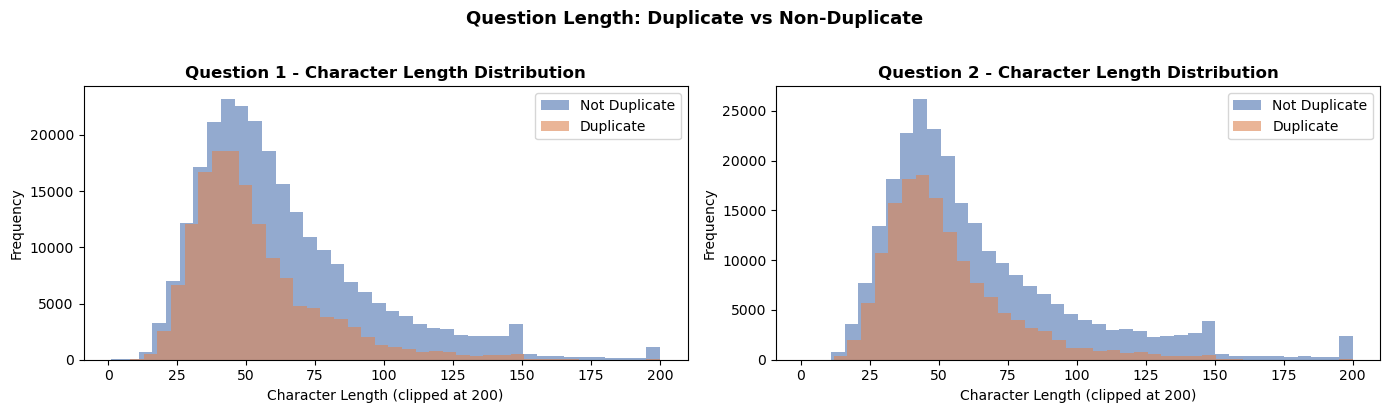

In [6]:
# --------- Question Length Distribution -----------------------
# Helps in spotting structural patterns between duplicates and non-duplicates

df["q1_char_len"] = df["question1"].astype(str).str.len()
df["q2_char_len"] = df["question2"].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(axes,
                           ["q1_char_len", "q2_char_len"],
                           ["Question 1", "Question 2"]):
    for dup, color, lbl in [(0, "#4C72B0", "Not Duplicate"),
                             (1, "#DD8452", "Duplicate")]:
        subset = df[df["is_duplicate"] == dup][col]
        ax.hist(subset.clip(0, 200), bins=40, alpha=0.6,
                color=color, label=lbl, edgecolor="none")
    ax.set_title(f"{label} - Character Length Distribution", fontweight="bold")
    ax.set_xlabel("Character Length (clipped at 200)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Question Length: Duplicate vs Non-Duplicate", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# ----------------- Repeated Questions -------------------------------------
all_questions = pd.Series(df["question1"].tolist() + df["question2"].tolist())
print(f"Total question slots    : {len(all_questions):,}")
print(f"Unique questions        : {all_questions.nunique():,}")
print(f"Top 5 most-repeated questions:")
print(all_questions.value_counts().head())

Total question slots    : 808,580
Unique questions        : 537,360
Top 5 most-repeated questions:
What are the best ways to lose weight?                                             161
How can you look at someone's private Instagram account without following them?    120
How can I lose weight quickly?                                                     111
What's the easiest way to make money online?                                        88
Can you see who views your Instagram?                                               79
Name: count, dtype: int64


## 4. Text Processing

We normalise raw question text before feature extraction:
- Convert to lowercase
- Expand currency symbols and large numbers into readable tokens
- Expand English contractions (e.g. *won't* -> *will not*)
- Strip HTML tags
- Remove punctuation

In [8]:
def preprocess(q):

    q = str(q).lower().strip()

    # Replacing certain special characters with their string equivalents
    q = q.replace('%', ' percent ')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # The pattern ['math'] appears around 900 times in the whole dataset
    q = q.replace('[math]', '')

    # Replacing some numbers with string equivalents
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()

    # Remove Punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    return q

In [9]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [10]:
df['question1'] = df['question1'].apply(preprocess)
df['question2'] = df['question2'].apply(preprocess)
print("Preprocessing complete.")

Preprocessing complete.


In [11]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_char_len,q2_char_len
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,66,57
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,51,88
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,73,59
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,50,65
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,76,39


## 5. Basic Feature Engineering

In [12]:
df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()
df['q1_num_words'] = df['question1'].apply(lambda row: len(row.split(" ")))
df['q2_num_words'] = df['question2'].apply(lambda row: len(row.split(" ")))

def common_words(row):
    w1 = set(row["question1"].lower().split())
    w2 = set(row["question2"].lower().split())
    return len(w1 & w2)

def total_words(row):
    w1 = set(row["question1"].lower().split())
    w2 = set(row["question2"].lower().split())
    return len(w1) + len(w2)

df["word_common"] = df.apply(common_words, axis=1)
df["word_total"]  = df.apply(total_words,  axis=1)
df["word_share"]  = round(df["word_common"] / df["word_total"].replace(0, 1), 2)

print("Basic features added.")
df[["question1","question2","q1_len","q2_len",
    "q1_num_words","q2_num_words","word_common",
    "word_total","word_share","is_duplicate"]].head()

Basic features added.


,question1,question2,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,is_duplicate
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,65,56,14,12,11,23,0.48,0
1,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,50,87,12,17,7,24,0.29,0
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,72,58,14,10,4,24,0.17,0
3,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,49,58,12,16,0,20,0.00,0
4,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,75,38,15,7,4,20,0.20,0


## 6.Advanced Token Based Features

In [13]:
import nltk
nltk.download("stopwords", quiet=True)

True

In [14]:
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))
SAFE_DIV   = 0.0001

def fetch_token_features(row):
    q1 = row['question1']
    q2 = row['question2']

    token_features = [0.0]*8

    # converting the sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords from Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the Stopwords from Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common not-stopwords from question pairs
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from question pairs
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common tokens from question pairs
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both questions are same or not?
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word pf both questions are same or not?
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [15]:
token_features = df.apply(fetch_token_features, axis=1)

df["cwc_min"]        = list(map(lambda x: x[0], token_features))
df["cwc_max"]        = list(map(lambda x: x[1], token_features))
df["csc_min"]        = list(map(lambda x: x[2], token_features))
df["csc_max"]        = list(map(lambda x: x[3], token_features))
df["ctc_min"]        = list(map(lambda x: x[4], token_features))
df["ctc_max"]        = list(map(lambda x: x[5], token_features))
df["last_word_eq"]   = list(map(lambda x: x[6], token_features))
df["first_word_eq"]  = list(map(lambda x: x[7], token_features))

In [16]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_char_len,q2_char_len,q1_len,q2_len,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,66,57,65,56,...,23,0.48,0.999980,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,51,88,50,87,...,24,0.29,0.799984,0.399996,0.749981,0.599988,0.699993,0.466664,0.0,1.0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,73,59,72,58,...,24,0.17,0.399992,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,50,65,49,58,...,20,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,76,39,75,38,...,20,0.20,0.399992,0.199998,0.999950,0.666644,0.571420,0.307690,0.0,1.0


## 7. Length Based Features

In [49]:
!pip install distance

In [18]:
import distance

def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    length_features = [0.0] * 3  # abs_len_diff, mean_len, longest_common_substring_ratio

    # Feature 1: absolute length difference
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Feature 2: mean length
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    # Feature 3: longest common substring ratio
    strs = list(distance.lcsubstrings(q1, q2))
    if strs:  # make sure the list is not empty
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    else:
        length_features[2] = 0.0

    return length_features


In [19]:
length_features = df.apply(fetch_length_features, axis=1)

df['abs_len_diff']         = list(map(lambda x: x[0], length_features))
df['mean_len']             = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [20]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_char_len,q2_char_len,q1_len,q2_len,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,66,57,65,56,...,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0,2,13.0,0.982456
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,51,88,50,87,...,0.399996,0.749981,0.599988,0.699993,0.466664,0.0,1.0,5,12.5,0.588235
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,73,59,72,58,...,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0,4,12.0,0.169492
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,50,65,49,58,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1,11.5,0.040000
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,76,39,75,38,...,0.199998,0.999950,0.666644,0.571420,0.307690,0.0,1.0,6,10.0,0.153846


## 8. Fuzzy Features

In [21]:
!pip install fuzzywuzzy python-Levenshtein -q

In [22]:
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [23]:
fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
df['fuzz_ratio']         = list(map(lambda x: x[0], fuzzy_features))
df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
df['token_sort_ratio']   = list(map(lambda x: x[2], fuzzy_features))
df['token_set_ratio']    = list(map(lambda x: x[3], fuzzy_features))

In [24]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_char_len,q2_char_len,q1_len,q2_len,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,66,57,65,56,...,0.785709,0.0,1.0,2,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,51,88,50,87,...,0.466664,0.0,1.0,5,12.5,0.588235,66,74,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,73,59,72,58,...,0.285712,0.0,1.0,4,12.0,0.169492,54,53,66,66
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,50,65,49,58,...,0.000000,0.0,0.0,1,11.5,0.040000,36,39,37,36
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,76,39,75,38,...,0.307690,0.0,1.0,6,10.0,0.153846,46,55,47,67


## 9. Feature Visualisations 
These pairplots show how well each group of features separates duplicates from non-duplicates. Good features show clear cluster separation.

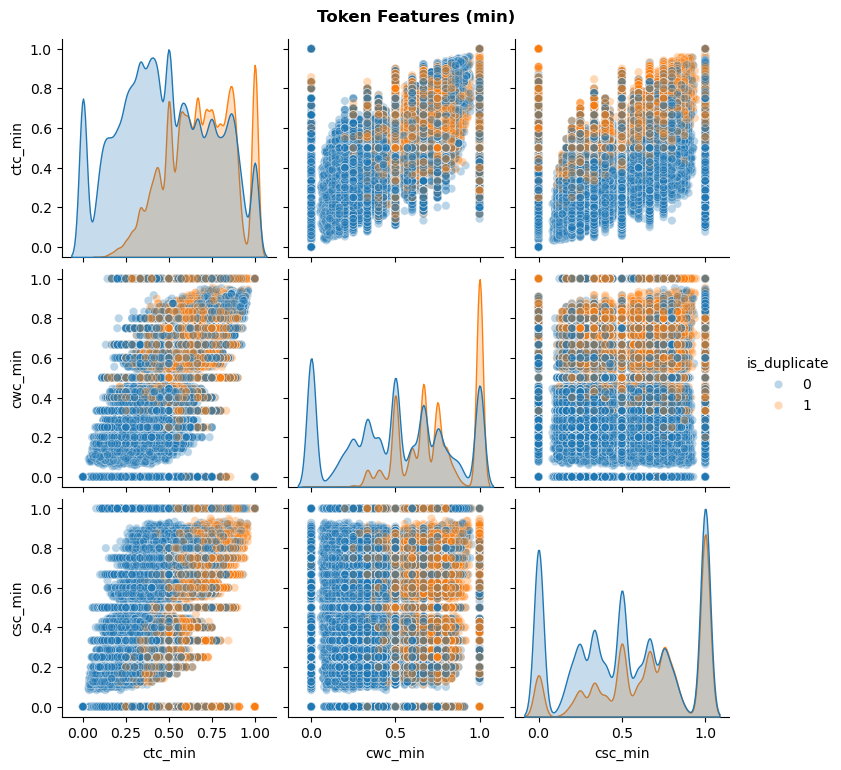

In [25]:
sns.pairplot(df[["ctc_min","cwc_min","csc_min","is_duplicate"]],
             hue="is_duplicate", plot_kws={"alpha": 0.3})
plt.suptitle("Token Features (min)", y=1.02, fontweight="bold")
plt.show()

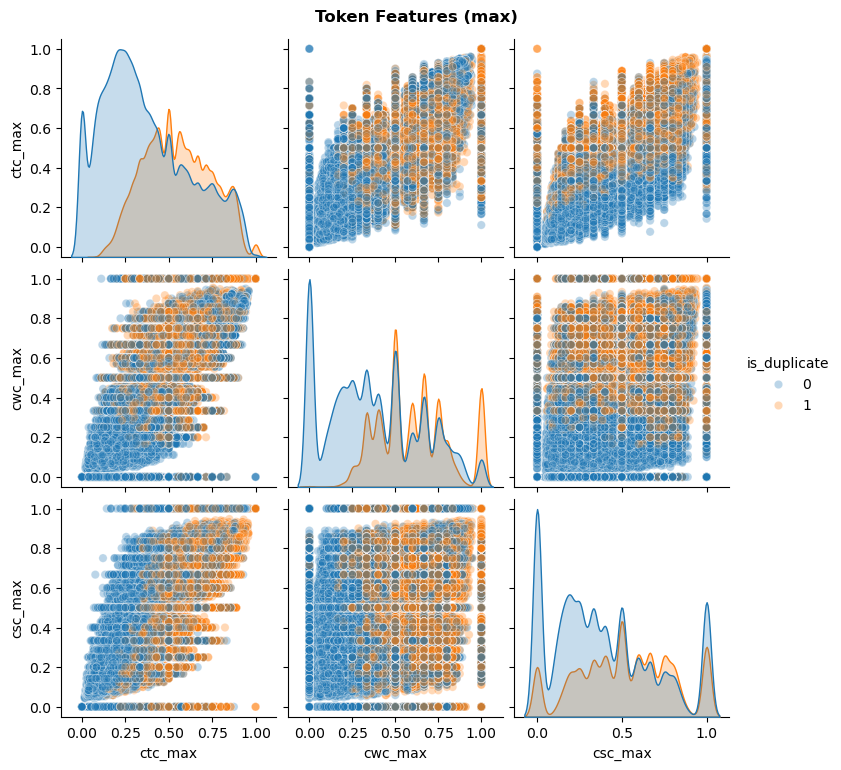

In [26]:
sns.pairplot(df[["ctc_max","cwc_max","csc_max","is_duplicate"]],
             hue="is_duplicate", plot_kws={"alpha": 0.3})
plt.suptitle("Token Features (max)", y=1.02, fontweight="bold")
plt.show()

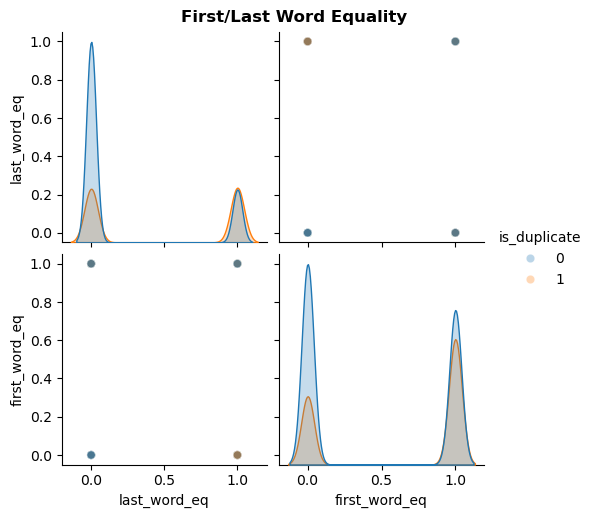

In [27]:
sns.pairplot(df[["last_word_eq","first_word_eq","is_duplicate"]],
             hue="is_duplicate", plot_kws={"alpha": 0.3})
plt.suptitle("First/Last Word Equality", y=1.02, fontweight="bold")
plt.show()

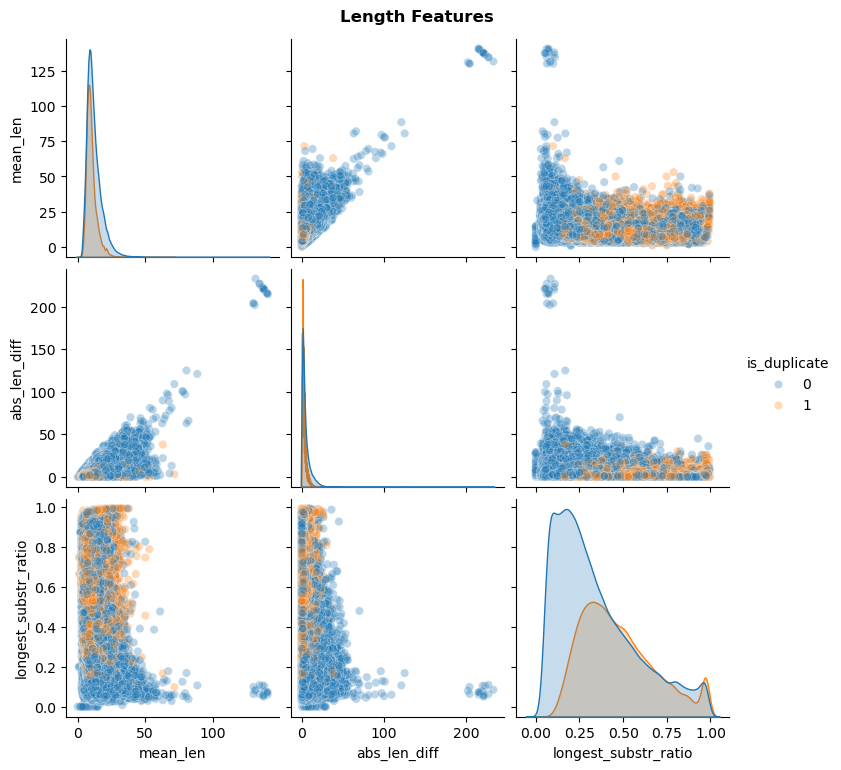

In [28]:
sns.pairplot(df[["mean_len","abs_len_diff","longest_substr_ratio","is_duplicate"]],
             hue="is_duplicate", plot_kws={"alpha": 0.3})
plt.suptitle("Length Features", y=1.02, fontweight="bold")
plt.show()

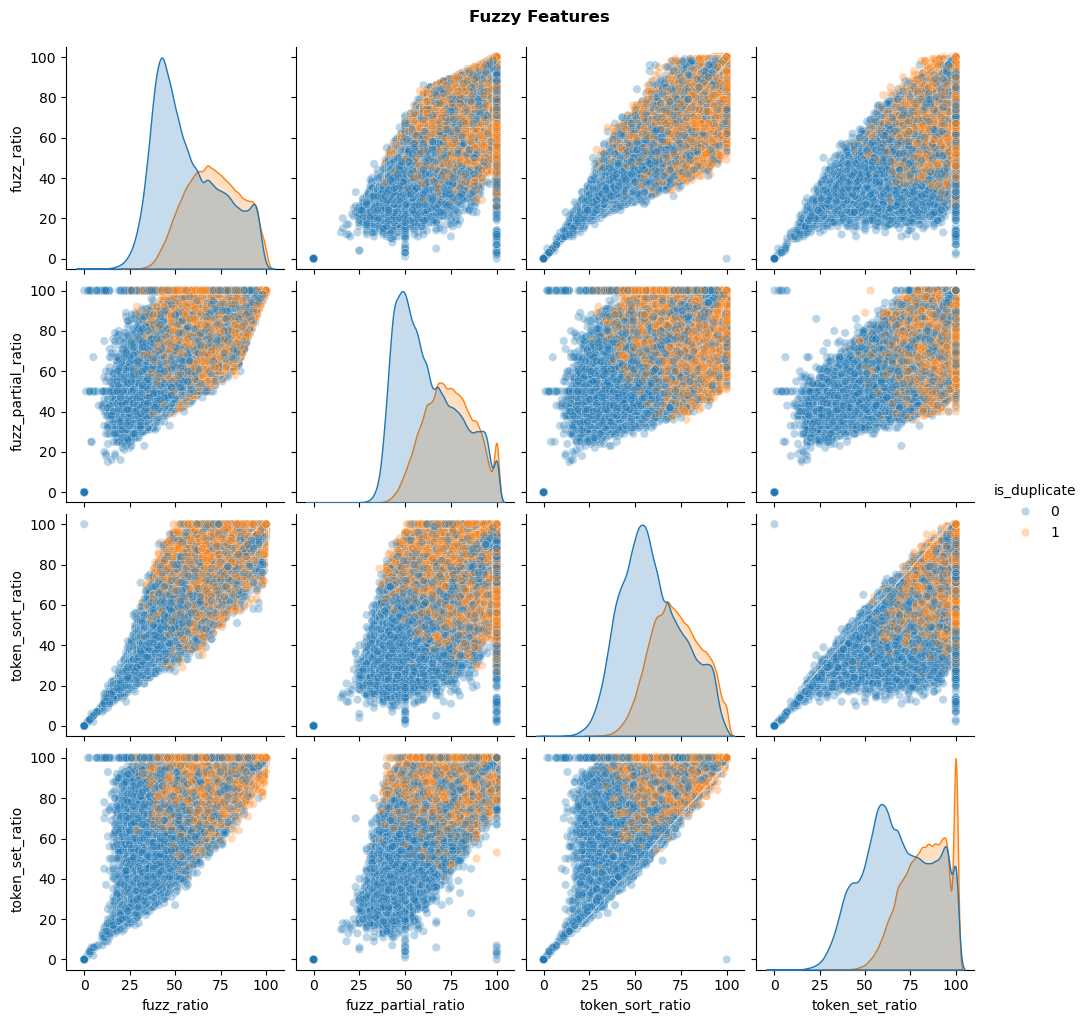

In [29]:
sns.pairplot(df[["fuzz_ratio","fuzz_partial_ratio","token_sort_ratio","token_set_ratio","is_duplicate"]],
             hue="is_duplicate", plot_kws={"alpha": 0.3})
plt.suptitle("Fuzzy Features", y=1.02, fontweight="bold")
plt.show()

## 10. SBERT Semantic Embedding Features

In [30]:
from sentence_transformers import SentenceTransformer

In [31]:
# Loading Sbert
sbert = SentenceTransformer('all-MiniLM-L6-v2')

In [32]:
# Encoding all questions into embeddings
q1_embeddings = sbert.encode(df['question1'].fillna(""), show_progress_bar=True)
q2_embeddings = sbert.encode(df['question2'].fillna(""), show_progress_bar=True)

Batches:   0%|          | 0/12635 [00:00<?, ?it/s]

Batches:   0%|          | 0/12635 [00:00<?, ?it/s]

In [33]:
# Row-wise cosine similarity
q1_norm = q1_embeddings / np.linalg.norm(q1_embeddings, axis=1, keepdims=True)
q2_norm = q2_embeddings / np.linalg.norm(q2_embeddings, axis=1, keepdims=True)

In [34]:
df["sbert_cosine"]  = np.sum(q1_norm * q2_norm, axis=1)
df["sbert_absdiff"] = np.mean(np.abs(q1_embeddings - q2_embeddings), axis=1)
df["sbert_dot"]     = np.sum(q1_embeddings * q2_embeddings, axis=1)

In [35]:
print("SBERT features added.")
df[["sbert_cosine","sbert_absdiff","sbert_dot","is_duplicate"]].describe()

SBERT features added.


,sbert_cosine,sbert_absdiff,sbert_dot,is_duplicate
count,404290.000000,404290.000000,404290.000000,404290.000000
mean,0.662681,0.030458,0.662681,0.369198
std,0.268864,0.013350,0.268864,0.482588
min,-0.264113,0.000000,-0.264113,0.000000
25%,0.518903,0.020701,0.518903,0.000000
50%,0.740138,0.029178,0.740138,0.000000
75%,0.869108,0.039706,0.869108,1.000000
max,1.000000,0.063849,1.000000,1.000000


## 11. Class Imbalance Handling
The dataset has ~63% non-duplicates and ~37% duplicates. We ill use XGBoost to penalise errors on the miniority class

In [36]:
neg_count = (df["is_duplicate"] == 0).sum()
pos_count = (df["is_duplicate"] == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Negative samples : {neg_count:,}")
print(f"Positive samples : {pos_count:,}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")

Negative samples : 255,027
Positive samples : 149,263
scale_pos_weight : 1.7086


## 12. Model Training -> XGboost with Hyperparameter Tuning

In [38]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import xgboost as xgb

In [39]:
feature_cols = [
    # Token-based
    "cwc_min", "cwc_max", "csc_min", "csc_max",
    "ctc_min", "ctc_max", "last_word_eq", "first_word_eq",
    # Length-based
    "abs_len_diff", "mean_len", "longest_substr_ratio",
    # Fuzzy
    "fuzz_ratio", "fuzz_partial_ratio", "token_sort_ratio", "token_set_ratio",
    # SBERT semantic
    "sbert_cosine", "sbert_absdiff", "sbert_dot",
]

X = df[feature_cols]
y = df["is_duplicate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")

Train size : 323,432
Test  size : 80,858


In [40]:
param_grid = {
    "n_estimators"    : [300, 500, 800],
    "max_depth"       : [4, 6, 8, 10],
    "learning_rate"   : [0.01, 0.05, 0.1],
    "subsample"       : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,   # handles class imbalance
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
print("Best Parameters:", search.best_params_)
best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# 13. Model Evaluation
## 13.1 Held-out Test Set Metrics

In [42]:
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")
print("=" * 45)
print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Not Duplicate", "Duplicate"]))

  Accuracy  : 0.8257
  F1 Score  : 0.7907
  ROC-AUC   : 0.9137
Classification Report:
               precision    recall  f1-score   support

Not Duplicate       0.93      0.79      0.85     51005
    Duplicate       0.71      0.89      0.79     29853

     accuracy                           0.83     80858
    macro avg       0.82      0.84      0.82     80858
 weighted avg       0.85      0.83      0.83     80858



## 13.2 Confusion Matrix

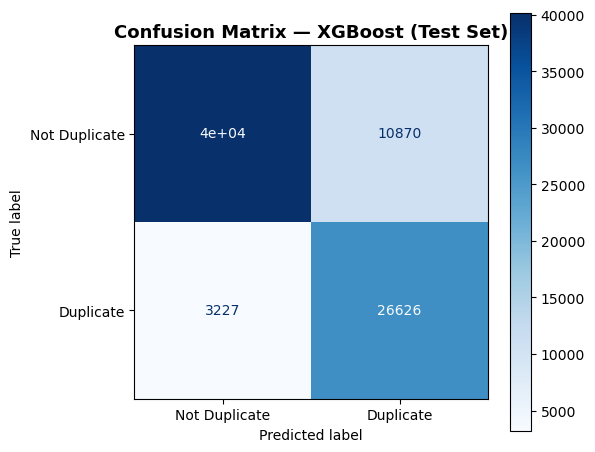

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Not Duplicate", "Duplicate"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — XGBoost (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 13.3 Cross-Validation

In [44]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="f1", n_jobs=-1)
print("Cross-Validation F1 Scores:", cv_scores.round(4))
print(f"Mean CV F1             : {cv_scores.mean():.4f}")
print(f"Std  CV F1             : {cv_scores.std():.4f}")

Cross-Validation F1 Scores: [0.7875 0.7915 0.787  0.7901 0.7889]
Mean CV F1             : 0.7890
Std  CV F1             : 0.0017


# 14. Save Model & Feature List

In [45]:
import pickle

with open("quora_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("quora_features.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Model saved  -> quora_best_model.pkl")
print("Features saved -> quora_features.pkl")

Model saved  -> quora_best_model.pkl
Features saved -> quora_features.pkl


# 15. Inference - Predict on a New Question Pair

In [48]:
def predict_duplicate(q1_raw, q2_raw, model, feature_cols, sbert_model, stop_words):
    """Return (prediction, probability) for a raw question pair."""
    q1 = preprocess(q1_raw)
    q2 = preprocess(q2_raw)

    row = pd.Series({"question1": q1, "question2": q2})

    # Basic
    feats = {}
    feats["word_share"] = len(set(q1.split()) & set(q2.split())) / (len(set(q1.split())) + len(set(q2.split())) + 1e-4)
    # Token
    tf = fetch_token_features(row)
    for col, val in zip(["cwc_min","cwc_max","csc_min","csc_max",
                          "ctc_min","ctc_max","last_word_eq","first_word_eq"], tf):
        feats[col] = val

    # Length
    lf = fetch_length_features(row)
    for col, val in zip(["abs_len_diff","mean_len","longest_substr_ratio"], lf):
        feats[col] = val

    # Fuzzy
    ff = fetch_fuzzy_features(row)
    for col, val in zip(["fuzz_ratio","fuzz_partial_ratio",
                          "token_sort_ratio","token_set_ratio"], ff):
        feats[col] = val

    # SBERT
    e1 = sbert_model.encode([q1])
    e2 = sbert_model.encode([q2])
    e1n = e1 / np.linalg.norm(e1)
    e2n = e2 / np.linalg.norm(e2)
    feats["sbert_cosine"]  = float(np.sum(e1n * e2n))
    feats["sbert_absdiff"] = float(np.mean(np.abs(e1 - e2)))
    feats["sbert_dot"]     = float(np.sum(e1 * e2))

    X_new = pd.DataFrame([feats])[feature_cols]
    pred  = model.predict(X_new)[0]
    prob  = model.predict_proba(X_new)[0][1]
    return pred, prob

# Example
q1_sample = "What is the best way to learn machine learning?"
q2_sample = "How can I start learning ML from scratch?"

pred, prob = predict_duplicate(q1_sample, q2_sample,
                               best_model, feature_cols,
                               sbert, STOP_WORDS)
print(f"Q1 : {q1_sample}")
print(f"Q2 : {q2_sample}")
print(f"Prediction  : {'Duplicate' if pred == 1 else 'Not Duplicate'}")
print(f"Probability : {prob:.4f}")

Q1 : What is the best way to learn machine learning?
Q2 : How can I start learning ML from scratch?
Prediction  : Not Duplicate
Probability : 0.0003
